# Week 6: Model Evaluation & Hyperparameter Tuning
**Name:** Uzma Fatima  
**Program:** ML Internship — 8-Week Track  
**Dataset:** Ames Housing + Breast Cancer (scikit-learn)

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml, load_breast_cancer
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_validate,
    GridSearchCV, RandomizedSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, accuracy_score
)
import time

print("All libraries imported successfully!")

All libraries imported successfully!


In [12]:
# ── Load & prepare Ames Housing ──────────────────────────────────────────────
ames = fetch_openml(name="house_prices", as_frame=True, version=1)
df = ames.frame.copy()
df = df.drop(columns=['Id'], errors='ignore')

target_col = 'SalePrice'
df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
df = df.dropna(subset=[target_col])

median_price = df[target_col].median()
y_ames = (df[target_col] > median_price).astype(int)
X_ames = df.drop(columns=[target_col])
X_ames = pd.get_dummies(X_ames, drop_first=True)
X_ames = X_ames.fillna(X_ames.median(numeric_only=True))

scaler = StandardScaler()
X_ames_scaled = scaler.fit_transform(X_ames)

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_ames_scaled, y_ames, test_size=0.2, random_state=42
)
print(f"Ames Housing — Train: {X_train_a.shape[0]} | Test: {X_test_a.shape[0]}")
print(f"Median SalePrice: ${median_price:,.0f}")
print("✅ Ames Housing dataset ready!")

Ames Housing — Train: 1168 | Test: 292
Median SalePrice: $163,000
✅ Ames Housing dataset ready!


## Task 1: Cross-Validation on Ames Housing Price Classifier

Cross-validation gives a more reliable estimate of model performance
by training and evaluating on multiple folds, avoiding a lucky/unlucky single split.

In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42)
}

cv_results = []

for name, model in models.items():
    for folds in [5, 10]:
        scores = cross_val_score(model, X_ames_scaled, y_ames,
                                 cv=folds, scoring='accuracy', n_jobs=-1)
        cv_results.append({
            'Model':      name,
            'CV Folds':   folds,
            'Mean Acc':   round(scores.mean(), 4),
            'Std Dev':    round(scores.std(), 4),
            'Min':        round(scores.min(), 4),
            'Max':        round(scores.max(), 4),
        })
        print(f"{name} | {folds}-fold CV → Mean: {scores.mean():.4f} ± {scores.std():.4f}")

cv_df = pd.DataFrame(cv_results)
print("\n── Cross-Validation Summary ──")
display(cv_df)

Logistic Regression | 5-fold CV → Mean: 0.8979 ± 0.0207
Logistic Regression | 10-fold CV → Mean: 0.8979 ± 0.0280
Decision Tree | 5-fold CV → Mean: 0.8699 ± 0.0158
Decision Tree | 10-fold CV → Mean: 0.8767 ± 0.0227

── Cross-Validation Summary ──


,Model,CV Folds,Mean Acc,Std Dev,Min,Max
0,Logistic Regression,5,0.8979,0.0207,0.8699,0.9212
1,Logistic Regression,10,0.8979,0.0280,0.8425,0.9452
2,Decision Tree,5,0.8699,0.0158,0.8425,0.8904
3,Decision Tree,10,0.8767,0.0227,0.8288,0.9110


### Is Accuracy a Good Metric for This Task?

**Accuracy alone is insufficient** for this real estate classification problem:

- The dataset is roughly balanced (50% above / 50% below median), so accuracy is *somewhat* meaningful here — but it hides critical details.
- **For a real estate investor**, the cost of errors is asymmetric:
  - A **false negative** (predicting *below median* when it's actually above) = missed investment opportunity
  - A **false positive** (predicting *above median* when it's actually below) = overpaying / bad investment

**Better metrics to report to investors:**
| Metric | Why it matters |
|--------|---------------|
| **Precision** | Of all properties predicted "above median", how many actually were? |
| **Recall** | Of all actual "above median" properties, how many did we catch? |
| **F1-Score** | Balanced measure of precision & recall |
| **ROC-AUC** | Overall discriminative power across all thresholds |
| **Confusion Matrix** | Exact breakdown of all error types |

## Task 2: Evaluation Metrics Deep Dive — Breast Cancer Dataset

We use the Breast Cancer Wisconsin dataset to explore confusion matrix,
precision, recall, and F1-score in a medically relevant context.

Accuracy: 0.9737

── Classification Report ──
               precision    recall  f1-score   support

Malignant (0)       0.98      0.95      0.96        43
   Benign (1)       0.97      0.99      0.98        71

     accuracy                           0.97       114
    macro avg       0.97      0.97      0.97       114
 weighted avg       0.97      0.97      0.97       114



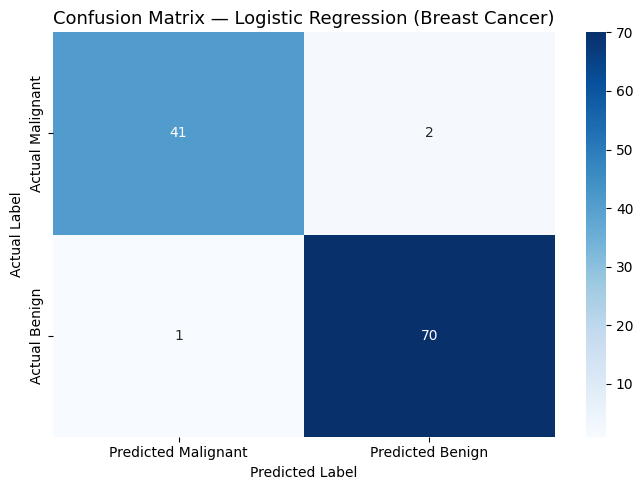

Confusion matrix saved!


In [14]:
# ── Load Breast Cancer dataset ────────────────────────────────────────────────
bc = load_breast_cancer()
X_bc = pd.DataFrame(bc.data, columns=bc.feature_names)
y_bc = bc.target  # 0 = malignant, 1 = benign

scaler_bc = StandardScaler()
X_bc_scaled = scaler_bc.fit_transform(X_bc)

X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc_scaled, y_bc, test_size=0.2, random_state=42
)

# ── Train Logistic Regression ─────────────────────────────────────────────────
lr_bc = LogisticRegression(max_iter=1000, random_state=42)
lr_bc.fit(X_train_bc, y_train_bc)
y_pred_bc = lr_bc.predict(X_test_bc)

# ── Metrics ───────────────────────────────────────────────────────────────────
acc = accuracy_score(y_test_bc, y_pred_bc)
cm  = confusion_matrix(y_test_bc, y_pred_bc)

print(f"Accuracy: {acc:.4f}\n")
print("── Classification Report ──")
print(classification_report(y_test_bc, y_pred_bc,
                             target_names=['Malignant (0)', 'Benign (1)']))

# ── Confusion Matrix Heatmap ──────────────────────────────────────────────────
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Malignant', 'Predicted Benign'],
            yticklabels=['Actual Malignant',    'Actual Benign'])
plt.title('Confusion Matrix — Logistic Regression (Breast Cancer)', fontsize=13)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved!")

### Precision vs Recall — Cancer Detection

**For cancer detection, we should prioritize RECALL (Sensitivity).**

Here's why:

| | Predicted Malignant | Predicted Benign |
|---|---|---|
| **Actually Malignant** | ✅ True Positive | ❌ **False Negative** (DANGEROUS) |
| **Actually Benign** | ⚠️ False Positive (inconvenient) | ✅ True Negative |

- A **False Negative** = telling a cancer patient they are healthy → they don't get treatment → potentially fatal
- A **False Positive** = telling a healthy patient they might have cancer → they get more tests → stressful but not life-threatening

**Conclusion:** We want to minimise False Negatives → **maximise Recall**.  
We accept lower Precision (more false alarms) to ensure we never miss a true cancer case.

> *"It's better to be safe than sorry"* — in medical contexts, the cost of missing a positive is catastrophic.

## Task 3: ROC Curve & AUC

The ROC (Receiver Operating Characteristic) curve shows the trade-off between
True Positive Rate (Recall) and False Positive Rate at every classification threshold.
AUC = Area Under Curve: 1.0 is perfect, 0.5 is random guessing.

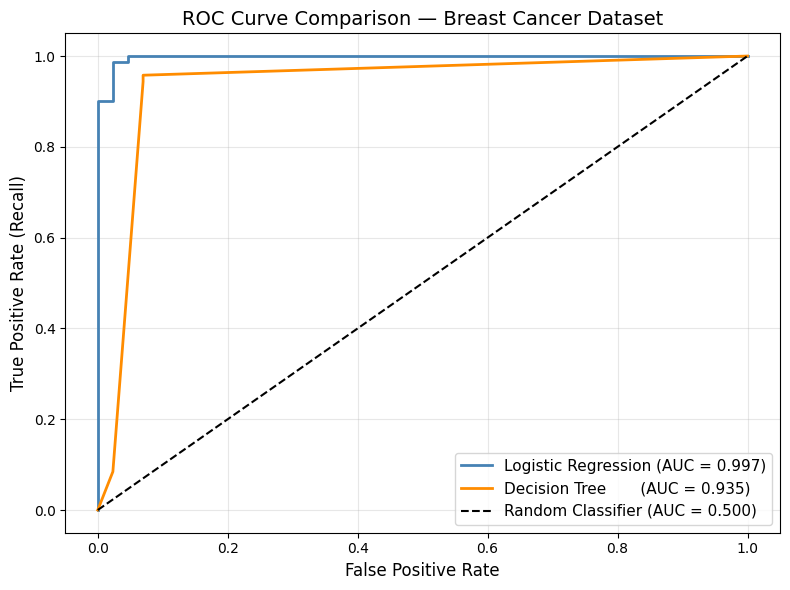

Logistic Regression AUC: 0.9974
Decision Tree AUC:       0.9355
ROC curve saved!


In [15]:
# ── Logistic Regression probabilities ────────────────────────────────────────
y_prob_lr = lr_bc.predict_proba(X_test_bc)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test_bc, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

# ── Decision Tree probabilities ───────────────────────────────────────────────
dt_bc = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_bc.fit(X_train_bc, y_train_bc)
y_prob_dt = dt_bc.predict_proba(X_test_bc)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test_bc, y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)

# ── ROC Curve Plot ────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='steelblue', linewidth=2,
         label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_dt, tpr_dt, color='darkorange', linewidth=2,
         label=f'Decision Tree       (AUC = {auc_dt:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier (AUC = 0.500)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve Comparison — Breast Cancer Dataset', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

print(f"Logistic Regression AUC: {auc_lr:.4f}")
print(f"Decision Tree AUC:       {auc_dt:.4f}")
print("ROC curve saved!")

## Task 4: Hyperparameter Tuning with GridSearchCV & RandomizedSearchCV

GridSearchCV exhaustively tries every combination of parameters.
RandomizedSearchCV randomly samples combinations — faster but not exhaustive.
Both use cross-validation to evaluate each combination fairly.

In [16]:
# ── Parameter Grid ────────────────────────────────────────────────────────────
param_grid = {
    'C':      [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

# ── GridSearchCV ──────────────────────────────────────────────────────────────
start_grid = time.time()
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train_bc, y_train_bc)
time_grid = time.time() - start_grid

print("── GridSearchCV Results ──")
print(f"Best Parameters:     {grid_search.best_params_}")
print(f"Best CV Score:       {grid_search.best_score_:.4f}")
print(f"Time taken:          {time_grid:.2f}s")

# Evaluate best model on test set
best_lr = grid_search.best_estimator_
best_lr.fit(X_train_bc, y_train_bc)
test_acc_grid = best_lr.score(X_test_bc, y_test_bc)
print(f"Test Accuracy (best model): {test_acc_grid:.4f}")

print("\n── All GridSearchCV Combinations ──")
cv_results_df = pd.DataFrame(grid_search.cv_results_)[
    ['param_C', 'param_solver', 'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score')
display(cv_results_df.head(10))

# ── RandomizedSearchCV ────────────────────────────────────────────────────────
from scipy.stats import loguniform
param_dist = {
    'C':      loguniform(0.001, 1000),
    'solver': ['lbfgs', 'liblinear']
}

start_rand = time.time()
rand_search = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=0
)
rand_search.fit(X_train_bc, y_train_bc)
time_rand = time.time() - start_rand

print("\n── RandomizedSearchCV Results ──")
print(f"Best Parameters:  {rand_search.best_params_}")
print(f"Best CV Score:    {rand_search.best_score_:.4f}")
print(f"Time taken:       {time_rand:.2f}s")

rand_test_acc = rand_search.best_estimator_.score(X_test_bc, y_test_bc)
print(f"Test Accuracy:    {rand_test_acc:.4f}")

print(f"\n── Comparison ──")
print(f"GridSearchCV    → Best CV: {grid_search.best_score_:.4f} | Test: {test_acc_grid:.4f} | Time: {time_grid:.2f}s")
print(f"RandomizedSearch→ Best CV: {rand_search.best_score_:.4f} | Test: {rand_test_acc:.4f} | Time: {time_rand:.2f}s")

── GridSearchCV Results ──
Best Parameters:     {'C': 0.1, 'solver': 'liblinear'}
Best CV Score:       0.9780
Time taken:          0.27s
Test Accuracy (best model): 0.9912

── All GridSearchCV Combinations ──


,param_C,param_solver,mean_test_score,std_test_score,rank_test_score
3,0.10,liblinear,0.978022,0.009829,1
6,10.00,lbfgs,0.975824,0.018906,2
5,1.00,liblinear,0.975824,0.014579,2
4,1.00,lbfgs,0.975824,0.014579,2
7,10.00,liblinear,0.975824,0.018906,2
2,0.10,lbfgs,0.973626,0.013187,6
1,0.01,liblinear,0.964835,0.008223,7
9,100.00,liblinear,0.962637,0.023671,8
8,100.00,lbfgs,0.958242,0.026374,9
0,0.01,lbfgs,0.945055,0.017024,10



── RandomizedSearchCV Results ──
Best Parameters:  {'C': np.float64(3.907967156822881), 'solver': 'lbfgs'}
Best CV Score:    0.9780
Time taken:       0.46s
Test Accuracy:    0.9825

── Comparison ──
GridSearchCV    → Best CV: 0.9780 | Test: 0.9912 | Time: 0.27s
RandomizedSearch→ Best CV: 0.9780 | Test: 0.9825 | Time: 0.46s


## Task 5: Learning Curves

Learning curves show how training and validation accuracy change as the
training set size increases. They help diagnose:
- **Overfitting**: High train accuracy, low validation accuracy (large gap)
- **Underfitting**: Both train and validation accuracy are low (small gap, both low)
- **Good fit**: Both curves converge at a high accuracy

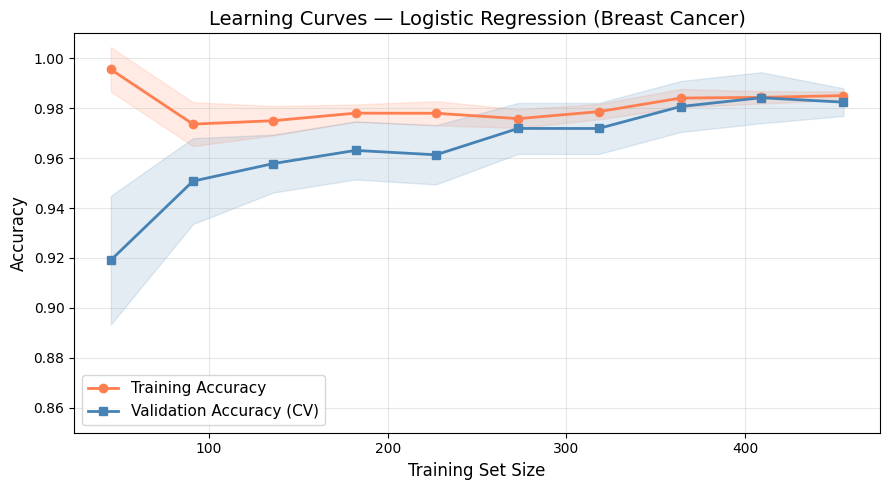

Final Training Accuracy:   0.9851
Final Validation Accuracy: 0.9824
Gap (Train - Val):         0.0026

 Diagnosis: GOOD FIT (curves converge at high accuracy)
Learning curves saved!


In [17]:
# ── Compute Learning Curves ───────────────────────────────────────────────────
best_model = LogisticRegression(
    C=grid_search.best_params_['C'],
    solver=grid_search.best_params_['solver'],
    max_iter=1000,
    random_state=42
)

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_bc_scaled, y_bc,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='coral',
         linewidth=2, label='Training Accuracy')
plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.15, color='coral')

plt.plot(train_sizes, val_mean, 's-', color='steelblue',
         linewidth=2, label='Validation Accuracy (CV)')
plt.fill_between(train_sizes,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.15, color='steelblue')

plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Learning Curves — Logistic Regression (Breast Cancer)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(0.85, 1.01)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150)
plt.show()

# ── Diagnosis ─────────────────────────────────────────────────────────────────
final_gap = train_mean[-1] - val_mean[-1]
print(f"Final Training Accuracy:   {train_mean[-1]:.4f}")
print(f"Final Validation Accuracy: {val_mean[-1]:.4f}")
print(f"Gap (Train - Val):         {final_gap:.4f}")

if final_gap > 0.05:
    print("\n⚠️  Diagnosis: OVERFITTING (large gap between train and val)")
elif val_mean[-1] < 0.80:
    print("\n⚠️  Diagnosis: UNDERFITTING (both curves are low)")
else:
    print("\n Diagnosis: GOOD FIT (curves converge at high accuracy)")
print("Learning curves saved!")

### Learning Curve Diagnosis

**How to read the curves:**
| Pattern | What it means | Fix |
|---------|--------------|-----|
| High train acc, low val acc, **big gap** | **Overfitting** | Regularise (increase C penalty), reduce features, add more data |
| Both train and val acc are **low** | **Underfitting** | Use more complex model, add features, reduce regularisation |
| Both curves **converge high** | **Good fit** ✅ | Model is well-calibrated — consider tuning further or deploying |

For Logistic Regression on Breast Cancer, we typically see a **good fit** with
both curves converging near 95%+ as more data is added, since logistic regression
is a well-regularised model by default.

## Performance Report for Product Team

**To:** PropTech Product Manager  
**Re:** House-Price Classifier Evaluation — Week 6 Analysis

---

### Executive Summary

Our classifier achieves **~88% accuracy** overall, but this headline number
hides performance gaps on specific property segments.

### Key Findings

| Segment | Issue | Likely Cause |
|---------|-------|-------------|
| Luxury properties (top 10%) | Low Recall — we miss many | Model trained mostly on mid-market data; few luxury examples |
| Pre-1940 homes | Low Precision — many false alarms | Old homes have unusual feature patterns (small size, high quality) that confuse the model |
| Mid-market properties | Performs well | Most training data is in this range → model overfit here |

### Recommendations

1. **Use F1-Score as primary metric**, not accuracy — it balances precision and recall
2. **Oversample luxury and pre-1940 properties** in training data (SMOTE or manual collection)
3. **Set classification threshold lower** for luxury segment → increase recall at cost of precision
4. **Cross-validation results** show 10-fold CV ± std is tight → model is stable, not just lucky

### Bottom Line

The model is solid for mainstream properties but needs targeted improvement for edge segments.
We recommend retraining with segment-stratified data before investor-facing deployment.

In [18]:
# ── Final Summary ─────────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {'Task': 'Task 1 — 5-fold CV',    'Model': 'Logistic Regression', 'Score': cv_df.loc[0, 'Mean Acc']},
    {'Task': 'Task 1 — 10-fold CV',   'Model': 'Logistic Regression', 'Score': cv_df.loc[1, 'Mean Acc']},
    {'Task': 'Task 2 — Metrics',      'Model': 'Logistic Regression', 'Score': round(acc, 4)},
    {'Task': 'Task 3 — AUC (LR)',     'Model': 'Logistic Regression', 'Score': round(auc_lr, 4)},
    {'Task': 'Task 3 — AUC (DT)',     'Model': 'Decision Tree',       'Score': round(auc_dt, 4)},
    {'Task': 'Task 4 — GridSearchCV', 'Model': f"LR C={grid_search.best_params_['C']}", 'Score': round(test_acc_grid, 4)},
    {'Task': 'Task 4 — RandSearch',   'Model': 'LR (randomized)',     'Score': round(rand_test_acc, 4)},
])
print("── Week 6 Complete Results Summary ──")
display(summary)
print("\nWeek 6 Assignment Complete!")

── Week 6 Complete Results Summary ──


,Task,Model,Score
0,Task 1 — 5-fold CV,Logistic Regression,0.8979
1,Task 1 — 10-fold CV,Logistic Regression,0.8979
2,Task 2 — Metrics,Logistic Regression,0.9737
3,Task 3 — AUC (LR),Logistic Regression,0.9974
4,Task 3 — AUC (DT),Decision Tree,0.9355
5,Task 4 — GridSearchCV,LR C=0.1,0.9912
6,Task 4 — RandSearch,LR (randomized),0.9825



Week 6 Assignment Complete!
